# Machine Learning Foundations

## Breast Cancer Classification using Classical Machine Learning Algorithms

**Author:** Dvir

---

### Project Goal

The goal of this project is to build, train, evaluate, and compare several classical Machine Learning classification algorithms using the Breast Cancer Wisconsin Dataset.

The project demonstrates a complete Machine Learning workflow, including:

- Data exploration (EDA)
- Data preprocessing
- Model training
- Model evaluation
- Cross Validation
- Performance comparison

---

### Algorithms Used

- Logistic Regression
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)
- K-Nearest Neighbors (KNN)

# Table of Contents

1. Introduction
2. Dataset Overview
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Train-Test Split
6. Logistic Regression
7. Decision Tree
8. Random Forest
9. Support Vector Machine (SVM)
10. K-Nearest Neighbors (KNN)
11. Cross Validation
12. Model Comparison
13. Final Conclusions

# Introduction

Machine Learning provides a variety of algorithms for solving classification problems. In this project, several classical Machine Learning models are trained and evaluated using the Breast Cancer Wisconsin Dataset.

The objective is not only to achieve high accuracy, but also to compare the strengths and weaknesses of each algorithm using multiple evaluation metrics.

# Dataset Overview

The Breast Cancer Wisconsin Dataset is a binary classification dataset commonly used for evaluating Machine Learning algorithms.

It contains features extracted from digitized images of breast tissue samples. The objective is to classify each sample as either:

- Malignant (Cancerous)
- Benign (Non-cancerous)

### Dataset Information

- Number of samples: 569
- Number of features: 30
- Number of classes: 2

# Exploratory Data Analysis (EDA)

Before training the models, it is important to explore the dataset and understand its structure.

In this section, we examine:

- The dataset structure
- Feature names
- Summary statistics
- Class distribution
- Missing values

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer


What is a DataFrame?

A DataFrame is the main data structure in Pandas.

It can be thought of as an Excel spreadsheet inside Python.

## Display the First Rows

The first few rows provide a quick overview of the dataset structure and feature values.

## Preview the Dataset

Displaying the first five rows provides an initial overview of the dataset, including the available features and their values.

In [42]:
cancer = load_breast_cancer()


df = pd.DataFrame(
    cancer.data,
    columns=cancer.feature_names
)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Dataset Dimensions

The first step is to examine the size of the dataset by checking the number of samples and features.

In [43]:
df.shape


(569, 30)

In [44]:
df["target"] = cancer.target # היא להוסיף עמודה חדשה של המטרה כך שלכל מטופל תהיה גם התשובה הנכונה.
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Dataset Information

The following output provides information about the dataset, including the number of entries, data types, and whether any missing values are present.

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

## Summary Statistics

Summary statistics provide an overview of the numerical features, including measures such as the mean, standard deviation, minimum, maximum, and quartiles.

In [46]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


## Class Distribution

The distribution of the target classes is examined to determine whether the dataset is balanced. A balanced dataset helps machine learning models learn without being biased toward one class.

In [47]:
df["target"].value_counts()



,count
target,
1,357
0,212


## Missing Values

Checking for missing values is an essential preprocessing step. Missing data may negatively affect model performance and often requires additional handling.

In [48]:
df.isnull().sum()



,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


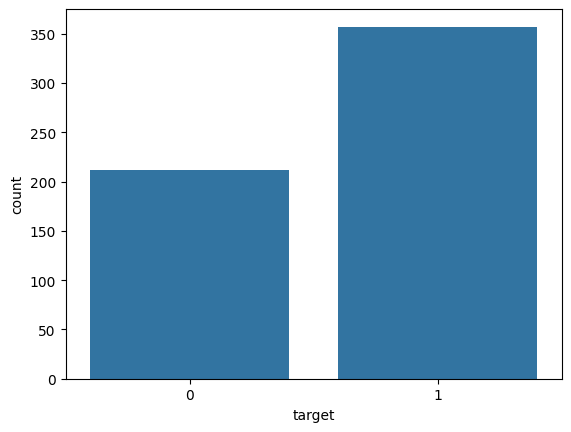

In [49]:
sns.countplot(x="target", data=df)
plt.show()

In [50]:
X = df.drop("target", axis=1)
y = df["target"]

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Training Set Size

The shape of the training dataset is displayed to verify the number of samples and features used for model training.

In [52]:
X_train.shape

(455, 30)

## Testing Set Size

The shape of the testing dataset is displayed to verify the number of unseen samples that will be used for model evaluation.

In [53]:
X_test.shape

(114, 30)

--------------------------------------------------------------------------------

# Model Training and Evaluation

In this section, several supervised machine learning algorithms are trained and evaluated on the Breast Cancer Wisconsin dataset. Each model is assessed using accuracy, confusion matrix, and classification metrics.

## Logistic Regression

Logistic Regression is a linear classification algorithm commonly used for binary classification problems. It estimates the probability that a sample belongs to a particular class using the logistic (sigmoid) function.

# Model Training and Evaluation

In this section, several supervised machine learning algorithms are trained and evaluated using the Breast Cancer Wisconsin dataset.

Each model is evaluated using:

- Accuracy
- Confusion Matrix
- Classification Report

In [54]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [55]:
model.predict(X_test)

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0])

In [56]:
y_test.values

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0])

In [57]:
y_pred = model.predict(X_test)
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,1,1
1,0,0
2,0,0
3,1,1
4,1,1
5,0,0
6,0,0
7,0,0
8,1,1
9,1,1


### Model Accuracy

The model accuracy is calculated on the testing dataset.

In [58]:
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, y_pred)

print(f"the accuracy is: {lr_accuracy*100:.2f}%" )

the accuracy is: 95.61%


### Confusion Matrix

The confusion matrix summarizes the model predictions by comparing the predicted labels with the true labels.

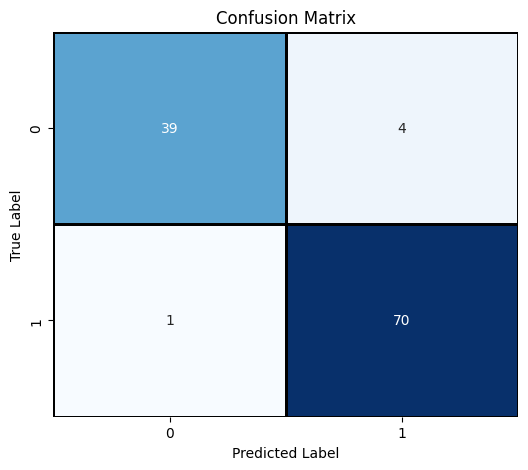

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=1,
    linecolor="black",
    cbar=False
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

### Classification Report

The classification report presents Precision, Recall, F1-score, and Support for each class.

In [60]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



--------------------------------------------------------------------------------

## Decision Tree

Decision Tree is a non-linear supervised learning algorithm that makes predictions by splitting the data into decision rules.

It is easy to interpret and can capture complex relationships between features without requiring feature scaling.

### Model Initialization
The Decision Tree classifier is initialized with the selected hyperparameters.

In [61]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)

### Model Training
The model is trained using the training dataset.

In [62]:
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [63]:
y_pred = model.predict(X_test)

### Model Accuracy
The model accuracy is evaluated using the testing dataset.

In [64]:
dt_accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {dt_accuracy*100:.2f}%")

Accuracy: 94.74%


### Confusion Matrix
The confusion matrix summarizes the model predictions by comparing the predicted labels with the true labels.

In [65]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

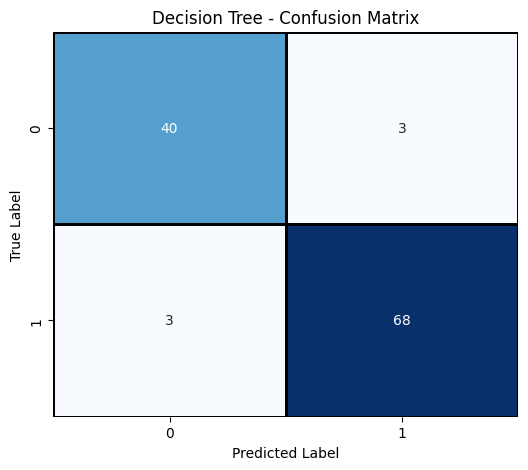

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=1,
    linecolor="black",
    cbar=False
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Decision Tree - Confusion Matrix")

plt.show()

### Classification Report
The classification report presents Precision, Recall, F1-score, and Support for each class.

In [67]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



--------------------------------------------------------------------------------

## Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [68]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)

In [69]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [70]:
y_pred = model.predict(X_test)

In [71]:
rf_accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {rf_accuracy*100:.2f}%")

Accuracy: 96.49%


In [72]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[40  3]
 [ 1 70]]


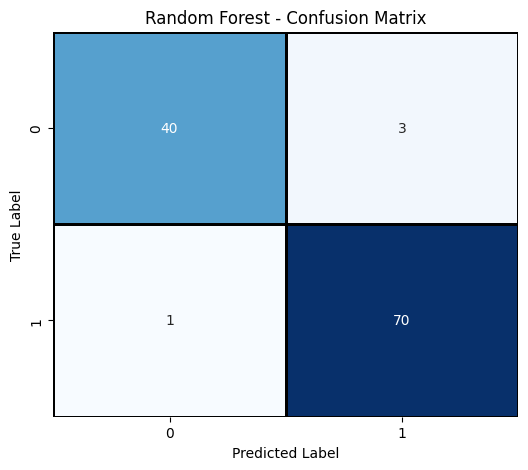

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=1,
    linecolor="black",
    cbar=False
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest - Confusion Matrix")

plt.show()

In [74]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



--------------------------------------------------------------------------------


## Support Vector Machine (SVM)

Support Vector Machine is a supervised learning algorithm that finds the optimal decision boundary between classes. It performs well on high-dimensional datasets and often provides strong classification performance.

In [75]:
from sklearn.svm import SVC
model = SVC(random_state=42)

In [76]:
model.fit(X_train, y_train)

SVC(random_state=42)

In [77]:
y_pred = model.predict(X_test)

In [78]:
svm_accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {svm_accuracy*100:.2f}%")

Accuracy: 94.74%


In [79]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[37  6]
 [ 0 71]]


In [80]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.86      0.93        43
           1       0.92      1.00      0.96        71

    accuracy                           0.95       114
   macro avg       0.96      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



-----------------------------------------------------------------------------

## K-Nearest Neighbors (KNN)

K-Nearest Neighbors is an instance-based learning algorithm that classifies a sample according to the labels of its nearest neighbors in the feature space.

In [81]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier()
K = 5

In [82]:
model.fit(X_train, y_train)

KNeighborsClassifier()

In [83]:
y_pred = model.predict(X_test)
y_pred


array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0])

In [84]:
knn_accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {knn_accuracy*100:.2f}%")

Accuracy: 95.61%


In [85]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[38  5]
 [ 0 71]]


In [86]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.88      0.94        43
           1       0.93      1.00      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



--------------------------------------------------------------------------------

# Model Comparison

The performance of all trained machine learning models is summarized below. Each model is evaluated using the same train-test split, allowing a fair comparison of their classification performance.

In [87]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Support Vector Machine",
        "K-Nearest Neighbors"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        svm_accuracy,
        knn_accuracy
    ]
})

comparison.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
2,Random Forest,0.964912
0,Logistic Regression,0.956140
4,K-Nearest Neighbors,0.956140
1,Decision Tree,0.947368
3,Support Vector Machine,0.947368


## Conclusion

Among the evaluated models, **Random Forest** and **Support Vector Machine (SVM)** achieved the highest classification accuracy on the Breast Cancer Wisconsin dataset.

Although all models performed well, ensemble methods such as Random Forest demonstrated excellent generalization performance, while SVM proved highly effective for this binary classification task.

In [89]:
comparison = comparison.sort_values(by="Accuracy", ascending=False)

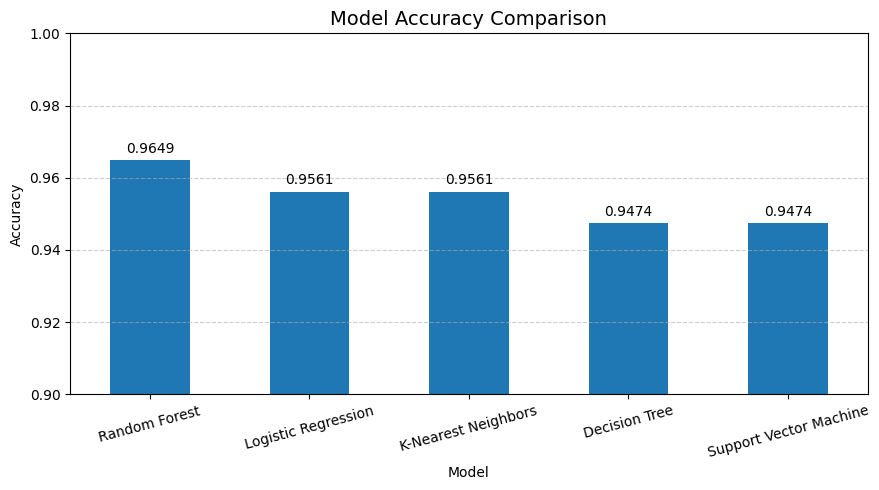

In [90]:
import matplotlib.pyplot as plt

ax = comparison.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    legend=False,
    figsize=(9, 5),
    rot=15
)

# Show only the relevant accuracy range
ax.set_ylim(0.90, 1.00)

# Labels
ax.set_title("Model Accuracy Comparison", fontsize=14)
ax.set_xlabel("Model")
ax.set_ylabel("Accuracy")

# Grid
ax.grid(axis="y", linestyle="--", alpha=0.6)

# Show values above bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.tight_layout()
plt.show()